# Build a Bayesian regression

CPU companion; no accelerator is required. TPU execution not validated.

- State the prior, likelihood and observation-noise assumptions
- Derive posterior precision and check a closed-form special case
- Compute latent and observation predictive variances separately
- Demonstrate prior strength and extrapolation effects

You have three noisy measurements and want to predict at a new input. A fitted line gives one answer, but how uncertain should that answer be? We will write a prior, combine it with a likelihood, solve the posterior exactly, and separate uncertainty about the line from noise in a new observation. This exact answer will become our reference when we build an approximate sampler.

## The idea

Bayesian regression represents uncertainty about parameters and propagates it to predictions. A latent-function prediction and a future noisy observation are different random quantities, so their intervals generally have different widths.

## Separate uncertainty about the function from observation noise

For features $x$, posterior parameter covariance $\Sigma$ gives latent predictive variance $x^T\Sigma x$. If independent observation noise has variance $\sigma^2$, a new observation has variance $x^T\Sigma x+\sigma^2$. Name each term before combining them.

Moving away from well-observed feature combinations can increase parameter-related uncertainty. It does not require the assumed observation-noise variance to change. Plot the posterior mean with separately labeled latent and observation bands to make this distinction visible.

The saved spread curves show how uncertainty varies with the input. They are conditional on the model, prior and noise assumptions. Check held-out behavior and model adequacy instead of reading any narrow posterior band as a guarantee.

### Pause and reason

Which interval is appropriate for a new noisy measurement?

<details><summary>Compare your reasoning</summary>

The posterior predictive interval that includes observation noise, under the model's assumptions. A latent-function interval omits that additional variability.

</details>

## State what is random

The features are fixed inputs. We treat the intercept and slope as uncertain, and condition on the observed targets. The prior scale $\tau=2$ expresses uncertainty about each weight before seeing these targets; it is not the sensor noise. The noise scale $\sigma=1$ describes repeated readings around the same latent line. We deliberately assume it known. Learning that scale would remove this exact two-parameter shortcut unless we used a richer conjugate model.

$$
w\sim\mathcal N(0,\tau^2 I),\qquad y\mid w,X\sim\mathcal N(Xw,\sigma^2 I)
$$

## Combine information through precision

Precision is inverse covariance: larger precision means less uncertainty. The prior contributes $I/\tau^2$; the observations contribute $X^\top X/\sigma^2$. The linear term is $X^\top y/\sigma^2$. Completing the square gives a linear system for the posterior mean. This resembles ridge regression because the posterior mode and mean coincide for this Gaussian model. That equivalence does not turn every regularized optimizer into a complete uncertainty model.

$$
\Lambda=\tau^{-2}I+\sigma^{-2}X^\top X,\quad \Sigma=\Lambda^{-1},\quad m=\Lambda^{-1}\sigma^{-2}X^\top y
$$

## Check the special case by hand

The inputs are $-1,0,1$, so their sum is zero and $X^\top X=\operatorname{diag}(3,2)$. The targets give $X^\top y=(3,4)$. Adding prior precision $1/4$ gives diagonal entries $13/4$ and $9/4$. Therefore $m=(12/13,16/9)$ and $\Sigma=\operatorname{diag}(4/13,4/9)$. These rational numbers provide an independent oracle; comparing two calls to the same posterior function would not.

## Two uncertainty bands answer two questions

At a design row $x_*$, the uncertain latent line value has variance $x_*^\top\Sigma x_*$. A new target adds independent observation variance $\sigma^2$. At input zero the latent variance is $4/13$, whereas the observation variance is $17/13$. At input two, the slope contribution increases latent variance to about $2.09$. A nominal Gaussian interval is conditional on this model and known noise scale; it is not proof that future real observations achieve nominal coverage.

$$
\mathbb E[y_*\mid D]=x_*^\top m,\qquad \operatorname{Var}(y_*\mid D)=x_*^\top\Sigma x_*+\sigma^2
$$

## Use a tiny exact model as an inference test

The next lesson compares approximate samples with this kind of known answer. This is a useful engineering habit: test an inference mechanism on a model you can solve before trusting it on one you cannot. Our design is synthetic and unusually well conditioned. Retain the prior, noise assumption and extrapolation range with your result; a narrow posterior can be confidently wrong when the likelihood is wrong.

## 1. Construct a small linear model

Create a fresh main.py. The first feature is an intercept. Targets contain three deliberately simple synthetic observations; the known noise scale is an assumption.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
X = jnp.array([[1.,-1.],[1.,0.],[1.,1.]])
y = jnp.array([-1.,1.,3.])
sigma, prior_scale = 1., 2.

The design has three rows and two columns. The weight vector contains intercept then slope.

## 2. Solve the posterior system

Append the conjugate update. Use a linear solve rather than writing an explicit matrix inverse for the mean.

In [2]:
def posterior(X,y,sigma,prior_scale):
    precision = jnp.eye(X.shape[1])/prior_scale**2 + X.T@X/sigma**2
    mean = jnp.linalg.solve(precision,X.T@y/sigma**2)
    covariance = jnp.linalg.solve(precision,jnp.eye(X.shape[1]))
    return mean,covariance
mean,cov = posterior(X,y,sigma,prior_scale)
assert jnp.allclose(mean,jnp.array([12/13,16/9]),atol=1e-6)
assert jnp.allclose(cov,jnp.diag(jnp.array([4/13,4/9])),atol=1e-6)

The independent fractions follow because centered inputs make the precision matrix diagonal.

## 3. Predict both the latent mean and a new observation

Append the prediction calculation, then run python main.py. Retain the two variance components separately.

In [3]:
def predictive(design,mean,cov,sigma):
    center = design@mean
    latent_variance = jnp.einsum('ni,ij,nj->n',design,cov,design)
    return center,latent_variance,latent_variance+sigma**2
query = jnp.array([[1.,0.],[1.,2.]])
center,latent_var,observation_var = predictive(query,mean,cov,sigma)
assert jnp.allclose(latent_var,jnp.array([4/13,4/13+16/9]),atol=1e-6)
assert jnp.allclose(observation_var-latent_var,1.)
print('posterior mean:',mean,'covariance:',cov)
print('latent variance:',latent_var,'observation variance:',observation_var)

posterior mean: [0.923077  1.7777778] covariance: [[0.30769232 0.        ]
 [0.         0.44444445]]
latent variance: [0.30769232 2.0854702 ] observation variance: [1.3076923 3.0854702]


The variance at the extrapolation input is larger because slope uncertainty contributes more strongly there.

## Run the example

In [4]:
import numpy as np
import jax
import jax.numpy as jnp
X = jnp.array([[1.,-1.],[1.,0.],[1.,1.]])
y = jnp.array([-1.,1.,3.])
sigma, prior_scale = 1., 2.

def posterior(X,y,sigma,prior_scale):
    precision = jnp.eye(X.shape[1])/prior_scale**2 + X.T@X/sigma**2
    mean = jnp.linalg.solve(precision,X.T@y/sigma**2)
    covariance = jnp.linalg.solve(precision,jnp.eye(X.shape[1]))
    return mean,covariance
mean,cov = posterior(X,y,sigma,prior_scale)
assert jnp.allclose(mean,jnp.array([12/13,16/9]),atol=1e-6)
assert jnp.allclose(cov,jnp.diag(jnp.array([4/13,4/9])),atol=1e-6)

def predictive(design,mean,cov,sigma):
    center = design@mean
    latent_variance = jnp.einsum('ni,ij,nj->n',design,cov,design)
    return center,latent_variance,latent_variance+sigma**2
query = jnp.array([[1.,0.],[1.,2.]])
center,latent_var,observation_var = predictive(query,mean,cov,sigma)
assert jnp.allclose(latent_var,jnp.array([4/13,4/13+16/9]),atol=1e-6)
assert jnp.allclose(observation_var-latent_var,1.)
print('posterior mean:',mean,'covariance:',cov)
print('latent variance:',latent_var,'observation variance:',observation_var)

posterior mean: [0.923077  1.7777778] covariance: [[0.30769232 0.        ]
 [0.         0.44444445]]
latent variance: [0.30769232 2.0854702 ] observation variance: [1.3076923 3.0854702]


Expected: The posterior mean is approximately $(0.9231,1.7778)$. Latent variances at inputs $0,2$ are approximately $0.3077,2.0855$; observation variances are each larger by $1$.

## Prediction uncertainty grows away from the observed center

Predict: Will an observation interval be wider or narrower than an interval for the latent line?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
grid=jnp.linspace(-3,3,61)
_,lv,ov=predictive(jnp.stack([jnp.ones_like(grid),grid],axis=1),mean,cov,sigma)
visual_data={"kind":"line","x":grid.tolist(),"xlabel":"input value","ylabel":"predictive standard deviation (target units)","series":[{"label":"latent line","y":jnp.sqrt(lv).tolist()},{"label":"new observation","y":jnp.sqrt(ov).tolist()}]}

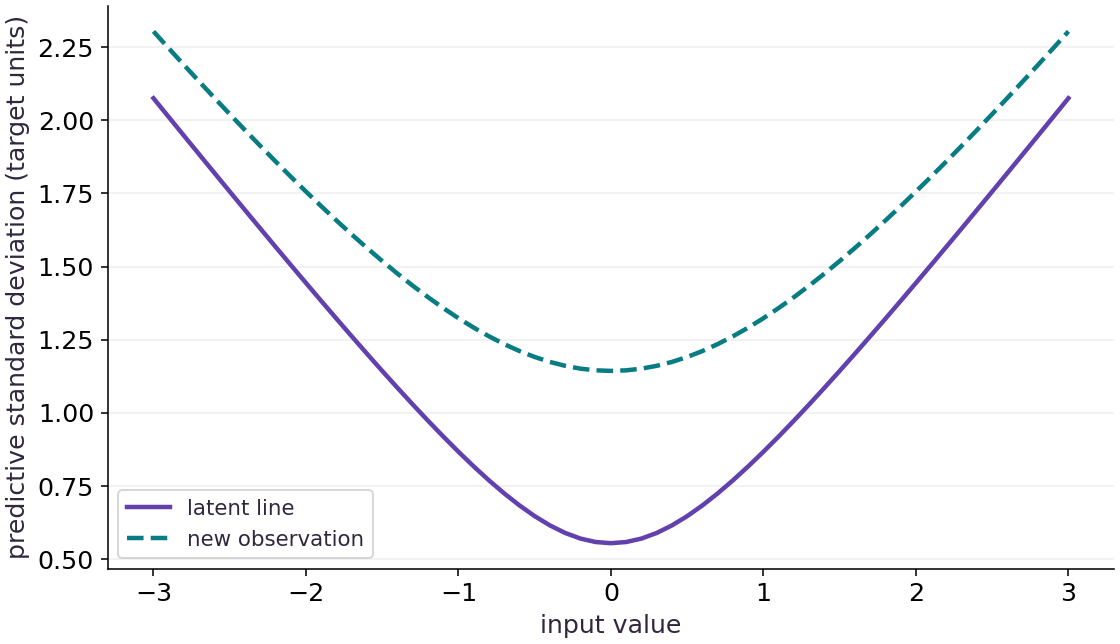

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is the input value. The vertical axis is predictive standard deviation, in target units. The lower curve propagates posterior weight uncertainty; the upper curve also adds the assumed observation noise before taking a square root. At input zero they are about $0.555$ and $1.144$. The curves rise symmetrically toward both ends because centered training inputs produce zero intercept-slope covariance.

### Connect it to the computation

The gap is not a fixed standard deviation of one: variances add, then we take the square root. The lower curve is narrowest near the observed center and grows under extrapolation. These are exact Gaussian-model standard deviations, not measured error bars or empirical coverage on a real test set.

## Repeat independent observations

Predict: If each observed design and target is repeated once as an independent measurement under the model, does posterior uncertainty increase or decrease?

In [7]:
repeat_mean,repeat_cov = posterior(jnp.tile(X,(2,1)),jnp.tile(y,2),sigma,prior_scale)
assert jnp.all(jnp.diag(repeat_cov)<jnp.diag(cov))
print(jnp.diag(repeat_cov))

[0.16       0.23529412]


Expected: Both posterior marginal variances decrease.

The calculation treats rows as independent new evidence. Duplicating a stored file does not create new evidence in a real dataset.

## Check the prior-only boundary

Predict: With no observations, what should the posterior return?

In [8]:
empty_mean,empty_cov = posterior(jnp.empty((0,2)),jnp.empty((0,)),sigma,prior_scale)
assert jnp.allclose(empty_mean,0.)
assert jnp.allclose(empty_cov,4*jnp.eye(2))

Expected: The mean is zero and covariance is $4I$.

The posterior recovers the prior when no likelihood information is present.

## Your exercise

Strengthen the prior by changing its scale from two to one half. Predict the direction of change in the weight norm and check it. Explain why a tighter posterior need not mean a better model.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
strong_mean,strong_cov = posterior(X,y,sigma,.5)
assert jnp.linalg.norm(strong_mean)<jnp.linalg.norm(mean)
assert jnp.all(jnp.diag(strong_cov)<jnp.diag(cov))

## Move away from centered inputs · Transfer / diagnosis

Use design rows $(1,0),(1,1),(1,2)$. Compare the JAX result with a host NumPy linear solve and show the posterior covariance is not diagonal.

Hint: The intercept and slope can compensate for each other when features are not centered.

In [11]:
# Write your attempt here.

## Reference reasoning

Nonzero covariance affects prediction uncertainty; keeping only marginal variances would lose the compensating relationship.

In [12]:
shift_X = jnp.array([[1.,0.],[1.,1.],[1.,2.]])
shift_m,shift_c = posterior(shift_X,y,sigma,prior_scale)
host_X=np.asarray(shift_X,dtype=np.float64)
host_P=np.eye(2)/4+host_X.T@host_X
np.testing.assert_allclose(shift_m,np.linalg.solve(host_P,host_X.T@np.asarray(y)),rtol=1e-5,atol=1e-6)
assert shift_c[0,1]<0

## Verify total predictive variance · Transfer / diagnosis

Draw posterior weights and independent observation noise. Compare empirical prediction variance at input zero to the analytic observation variance.

Hint: Use separate keys for weights and noise; sample with a Cholesky factor.

In [13]:
# Write your attempt here.

## Reference reasoning

A simulation verifies that the independent noise term belongs in predictions for observed targets.

In [14]:
kw,kn=jax.random.split(jax.random.key(37))
weights=mean+jax.random.normal(kw,(30000,2))@jnp.linalg.cholesky(cov).T
replicated=weights[:,0]+sigma*jax.random.normal(kn,(30000,))
assert abs(float(replicated.var())-float(observation_var[0]))<.07

## Checkpoint

Which variance describes a new noisy reading at a given input?

1. Only the posterior variance of the intercept
2. The propagated weight uncertainty plus observation-noise variance
3. The training mean squared error divided by the number of weights

## Diagnose

If an interval becomes implausibly narrow, print the latent and noise variance terms separately. If the slope is unexpectedly shrunk, inspect whether the prior scale was confused with prior precision. If targets have an extra column axis, reject the shape before a matrix operation silently changes the mean shape.

## Evidence

Precision derivation, exact fractional reference, host solve and predictive variance plot. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Posterior precision combines prior information with likelihood information.
- Latent uncertainty and future observation noise are separate quantities.
- An exact small model supplies an independent reference for approximate inference.

## Primary references

- [JAX linear solve](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.linalg.solve.html)
- [Stan posterior predictive checks](https://mc-stan.org/docs/stan-users-guide/posterior-predictive-checks.html)